## Import Libraries

In [42]:
import pandas as pd
from sklearn import ensemble, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# Needed to hide warnings in the matplotlib sections
import warnings
warnings.filterwarnings("ignore")

## Importing the dataset

In [43]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [44]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df[["Sales"]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

params = {
    "n_estimators": 1100, # Nombre d'arbres (Aucun progrès observé au dessus de 1100)
    "max_depth": 4, # Profondeur max de chaque arbre
    "learning_rate": 0.01, # eta : vitesse d'apprentissage à chaque itération
    "loss": "squared_error",
}
# + le nombre d'estimators est élevé, 
# - le learning rate doit être haut sinon l'algorithme est trop lent + risque d'overfitting

## Training

In [45]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=4, n_estimators=1100)

In [46]:
predictions = reg.predict(X_test)

Text(0, 0.5, 'Predicted Y')

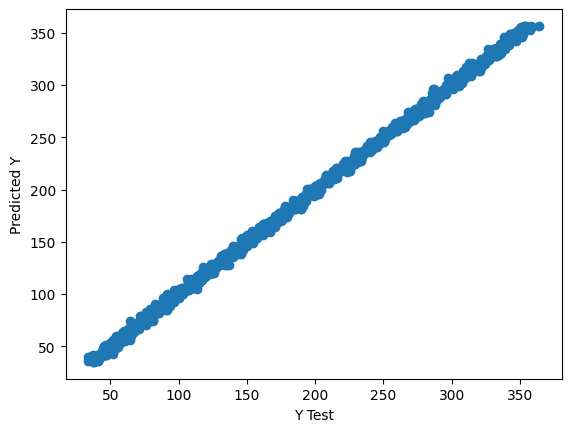

In [47]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

In [48]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")

MAE : 2.4423527376639917
MSE : 9.458973221955263
RMSE : 3.0755443781475926
R2 : 0.9989152126289909



## Export model

In [49]:
import pickle

# save
with open('../saved_models/gradient_boosting/model.pkl','wb') as f:
    pickle.dump(reg,f)

## Conclusion
Modèle non retenu : en comparaisaon avec le modèle de régression linéaire basique, l'écart quadratique moyen est plus élevé pour un algorithme plus long et plus lourd.